# Convolutional Neural Network %98 Accuracy

Hi everybody! I'm new into deep learning. I wrote this kernel to convert a application my learning. If this kernel is benefit for you or if there are your idea about this kernel. Please write comments. I'm wating your ideas about your kernel. 

Enjoy with Deep Learning !

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# data visualization
import matplotlib.pyplot as plt 
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Model Libraries
import keras 
from keras.models import Sequential
from keras.layers import Dense, Dropout,Flatten, Conv2D, MaxPooling2D

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/digit-recognizer/test.csv
/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv


In [2]:
train = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
test =  pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

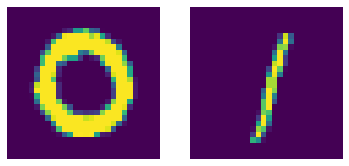

In [3]:
img_size = 28

train_piksel = np.array(train.drop("label",axis=1))
test_piksel = np.array(test)
test_piksel = test_piksel.reshape(test.shape[0],img_size,img_size,1)

plt.subplot(1,2,1)
plt.imshow(train_piksel[1].reshape(img_size, img_size))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(train_piksel[15].reshape(img_size, img_size))
plt.axis('off')
plt.show()

In this train dataframe has 42000 images (28x28 piksel) and 10 classes. I splitted as 70% train and 30% test dataset. 

In [4]:
num_classes = 10

X_train, X_test, Y_train, Y_test = train_test_split(train_piksel,train.loc[:,"label"],test_size=0.3)

X_train = X_train.reshape(X_train.shape[0],img_size,img_size,1)
X_test = X_test.reshape(X_test.shape[0],img_size,img_size,1)

Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

print("X_train.shape :",X_train.shape)
print("X_test.shape :",X_test.shape)
print("Y_train.shape :",Y_train.shape)
print("Y_test.shape :",Y_test.shape)

X_train.shape : (29400, 28, 28, 1)
X_test.shape : (12600, 28, 28, 1)
Y_train.shape : (29400, 10)
Y_test.shape : (12600, 10)


For this dataset, I used to LeNet5 model that is fisrt and famous CNN model. In this model was used to avareage pooling. But I wanted to use max pooling.

* The model => conv(6 filter) - maxpooling - conv(16 filter) - Full Connected - Full Connected - Dropout - Output Layer
* I used to ReLU as activation function. But this model was used to sigmoid and tan(h) as activation function.
* As last layer is output layer and the dataset contains multi classes, I used to softmax as activation function.

In [5]:
model = Sequential()
model.add(Conv2D(6, kernel_size=(5,5),activation="relu",input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(16, kernel_size=(5,5),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Flatten())
model.add(Dense(256,activation = "relu"))
model.add(Dense(128,activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 24, 24, 6)         156       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 6)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 8, 8, 16)          2416      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 4, 4, 16)          0         
_________________________________________________________________
flatten (Flatten)            (None, 256)               0         
_________________________________________________________________
dense (Dense)                (None, 256)               65792     
_________________________________________________________________
dense_1 (Dense)              (None, 128)               3

In [6]:
epochs = 20
batch_size = 86

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.fit(X_train,Y_train,epochs=epochs,batch_size=batch_size)

Epoch 1/20
342/342 [==============================] - 7s 20ms/step - loss: 1.9252 - accuracy: 0.7044
Epoch 2/20
342/342 [==============================] - 7s 20ms/step - loss: 0.3084 - accuracy: 0.9131
Epoch 3/20
342/342 [==============================] - 7s 19ms/step - loss: 0.1951 - accuracy: 0.9440
Epoch 4/20
342/342 [==============================] - 7s 20ms/step - loss: 0.1427 - accuracy: 0.9600
Epoch 5/20
342/342 [==============================] - 7s 21ms/step - loss: 0.1151 - accuracy: 0.9669
Epoch 6/20
342/342 [==============================] - 7s 19ms/step - loss: 0.0902 - accuracy: 0.9740
Epoch 7/20
342/342 [==============================] - 7s 20ms/step - loss: 0.0802 - accuracy: 0.9774
Epoch 8/20
342/342 [==============================] - 7s 19ms/step - loss: 0.0637 - accuracy: 0.9816
Epoch 9/20
342/342 [==============================] - 7s 19ms/step - loss: 0.0551 - accuracy: 0.9836
Epoch 10/20
342/342 [==============================] - 7s 21ms/step - loss: 0.0504 - accura

The results are more successful than that I waited. Image Agumentation can be made to increase accuracy. :) I compared the results with confusion matrix.

In [7]:
loss, acc = model.evaluate(X_test,Y_test)
print("loss :",loss)
print("accuracy :",acc)

394/394 [==============================] - 2s 4ms/step - loss: 0.1455 - accuracy: 0.9781
loss : 0.14548970758914948
accuracy : 0.9780952334403992


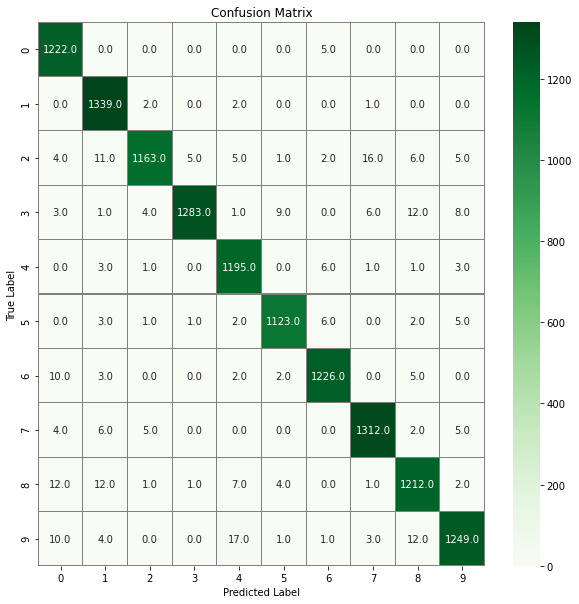

In [8]:
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred,axis = 1) 
Y_true = np.argmax(Y_test,axis = 1) 
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 

# plot the confusion matrix
f,ax = plt.subplots(figsize=(10, 10))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01,cmap="Greens",linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [9]:
#set ids as ImageId and predict label 
sId = pd.read_csv("/kaggle/input/digit-recognizer/sample_submission.csv")
ids = sId.drop("Label",axis=1)
predict = model.predict(test_piksel)
predict = np.argmax(predict,axis = 1) 

#set the output as a dataframe and convert to csv file named submission.csv
output = pd.DataFrame({ 'ImageId' : ids.ImageId, 'Label': predict})
output.to_csv('submission.csv', index=False)

# Conclusion

* Convolusion Neural Network is deep learning algorithm that is usually used to image recognizer project. 
* As technogy improved, new CNN models came up. But First and famous CNN model is LeNet5 model.
* It can be make image agumentation to increase accuracy. 